# Exercício 2, Simulação de consultório médico

**Hipótese usada:** o primeiro tempo entre chegadas representa a chegada do primeiro paciente após o início da simulação. Assim, as chegadas ocorrem nos tempos acumulados `5, 12, 15, 25, 31` minutos.

O relógio da simulação começa em `t = 0` e termina na última saída do sistema.

## a) Identificação dos elementos do sistema

**Enunciado:** Identifique as entidades do sistema, recursos, filas, eventos e variáveis de estado.

### Resposta

| Item | Identificação |
|---|---|
| Entidades | Pacientes |
| Recursos | 1 recepcionista, 1 sala de triagem, 2 médicos |
| Filas | Fila da recepção, fila da triagem, fila médica |
| Eventos | Chegada do paciente, início do cadastro, fim do cadastro, início da triagem, fim da triagem, início da consulta, fim da consulta, saída do sistema |
| Variáveis de estado | Número de pacientes na fila da recepção, número de pacientes na fila da triagem, número de pacientes na fila médica, estado da recepcionista, estado da sala de triagem, estado de cada médico, número de pacientes no sistema, relógio da simulação |

O sistema é uma rede de filas em série. O paciente passa primeiro pela recepção, depois pela triagem, depois pela fila médica e finalmente pela consulta. A disciplina de atendimento é FIFO.

## b) Diagrama ACD

**Enunciado:** Construa o Diagrama ACD, representando chegada dos pacientes, fila da recepção, triagem, fila médica, atendimento médico e saída do sistema.

### Resposta

O diagrama ACD abaixo mostra o ciclo completo da simulação por eventos discretos. Ele separa o avanço do relógio, os eventos incondicionais e as decisões condicionais que ativam os recursos quando existe fila aguardando.

- **Fase A:** avança o relógio para o próximo evento programado.
- **Fase B:** executa eventos que necessariamente ocorrem naquele instante, como chegada, fim de cadastro, fim de triagem e fim de consulta.
- **Fase C:** verifica condições para iniciar cadastro, triagem ou consulta, dependendo da existência de fila e disponibilidade do recurso.


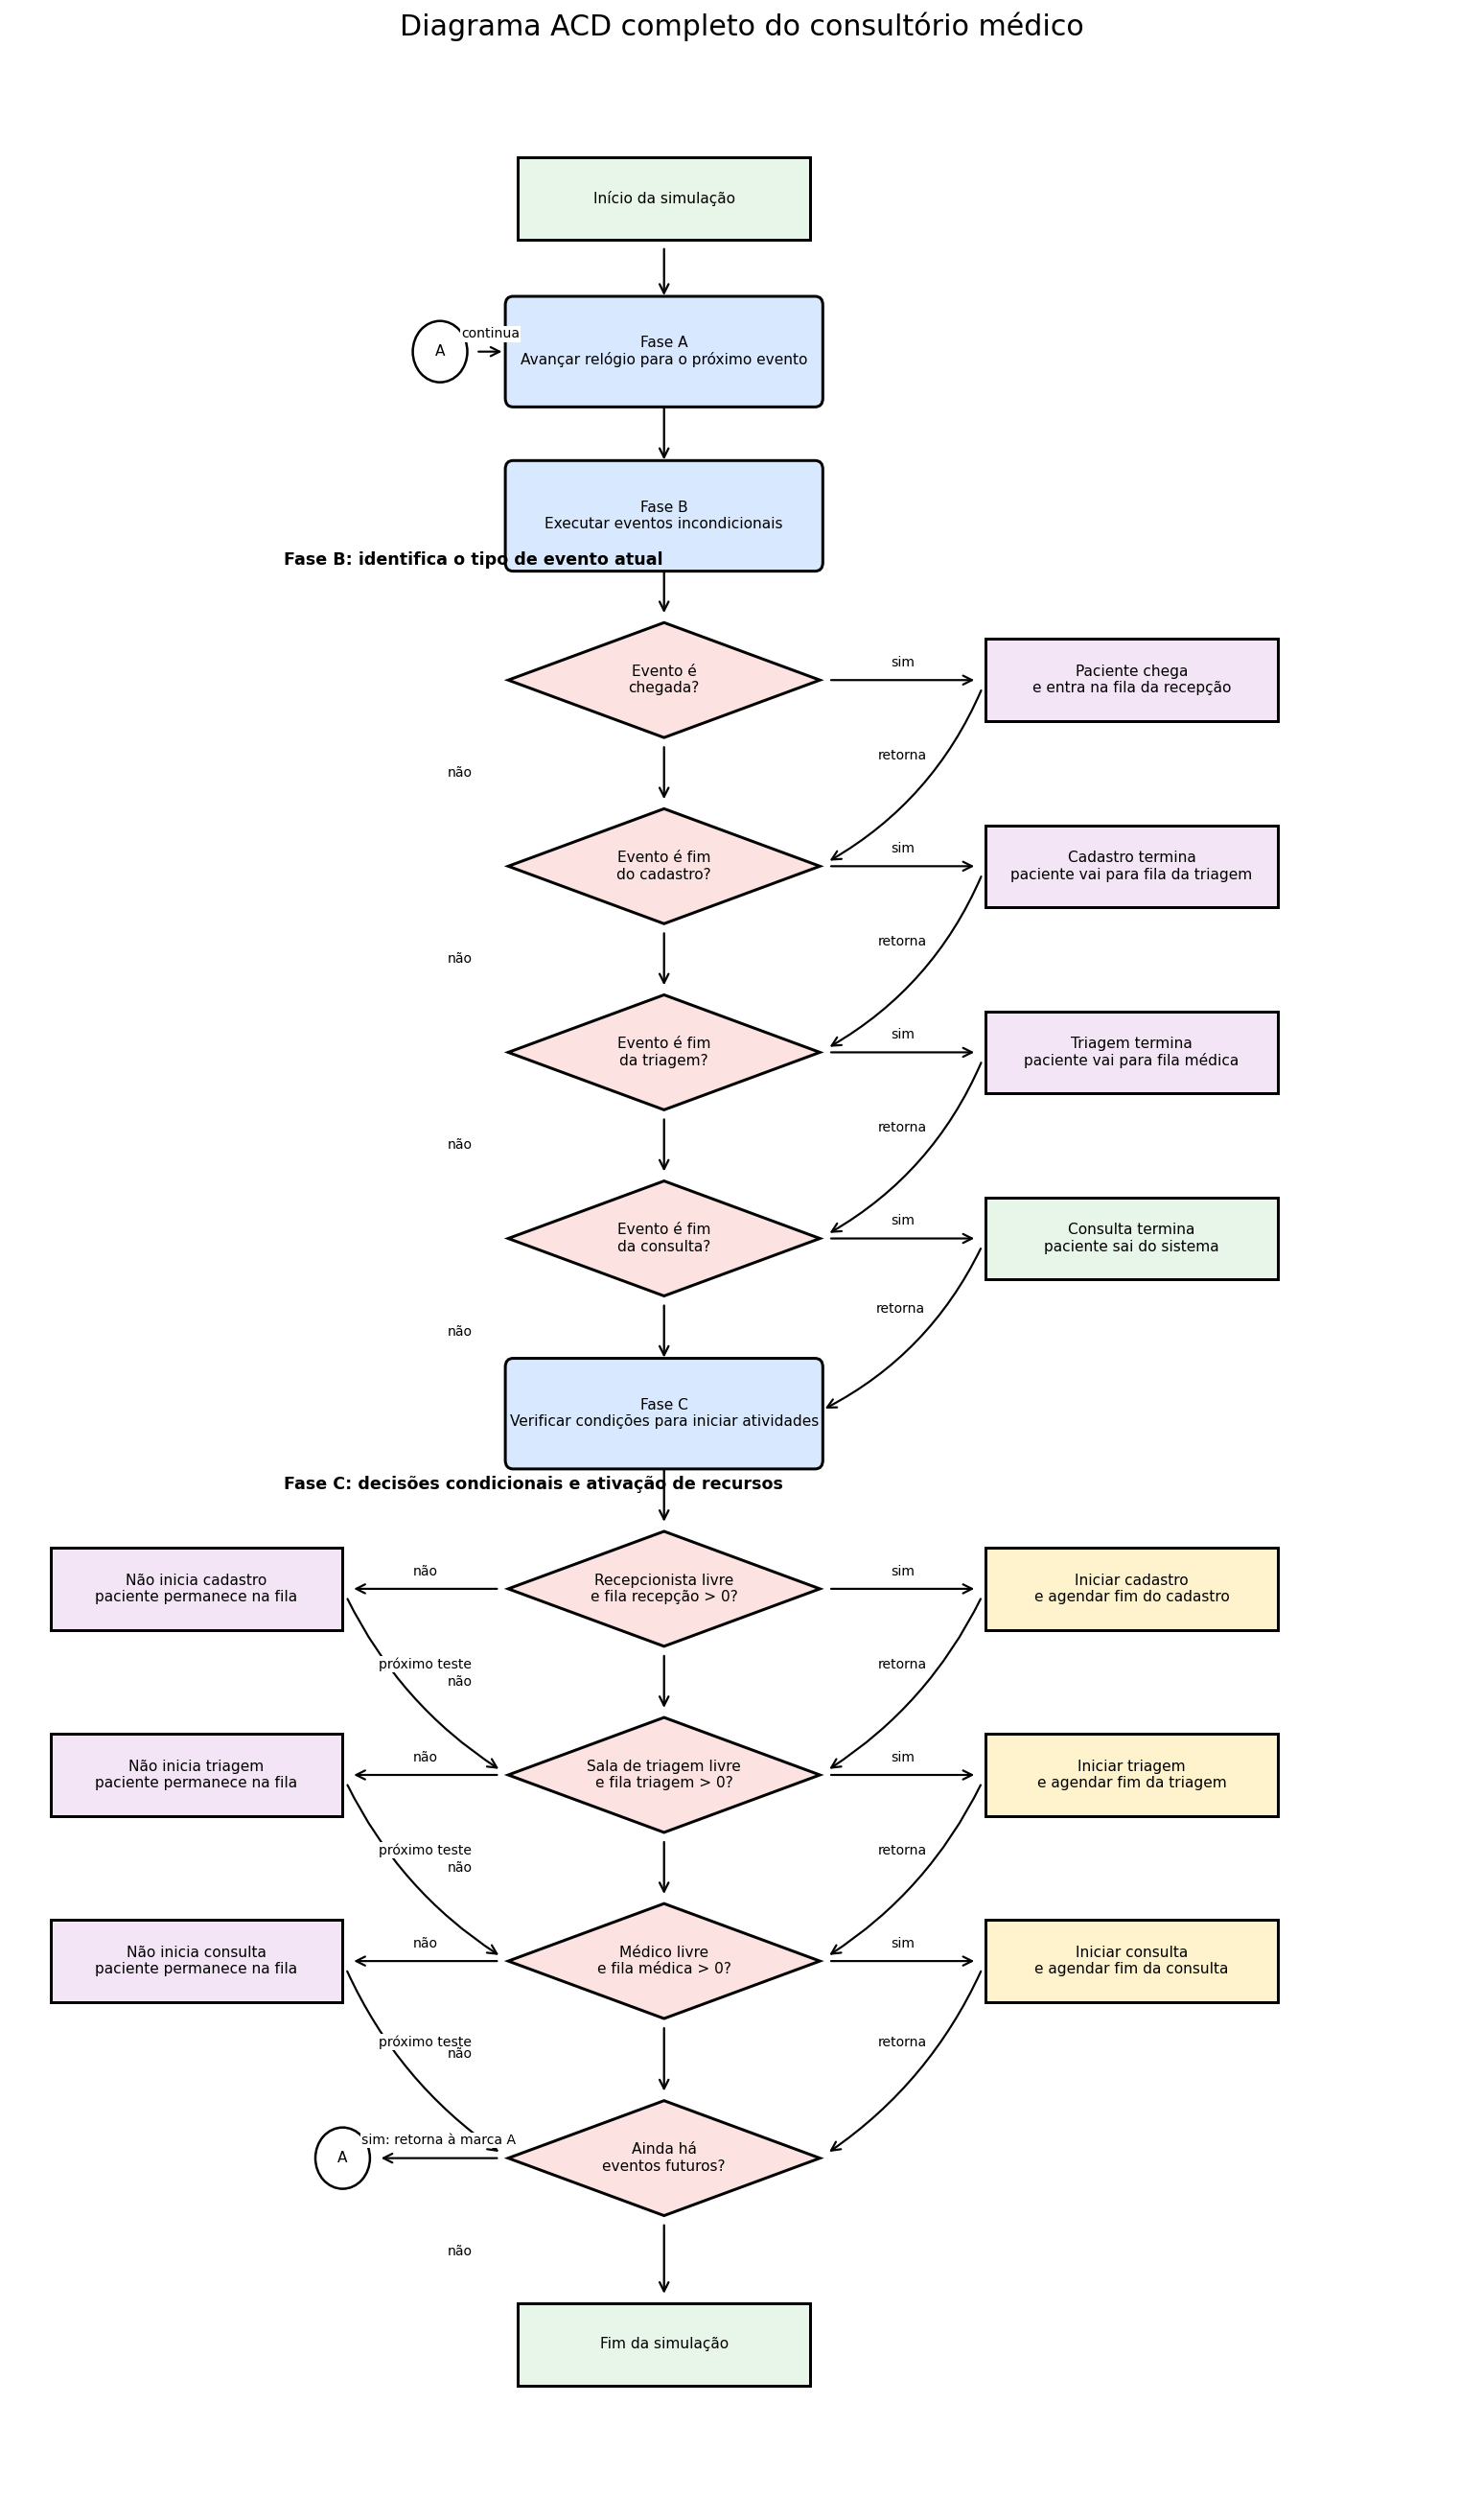

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, Polygon, FancyBboxPatch
from IPython.display import display

plt.rcParams["figure.dpi"] = 120

fig, ax = plt.subplots(figsize=(13, 22))
ax.axis("off")
ax.set_xlim(-1.5, 13.5)
ax.set_ylim(-3.1, 19.2)
ax.set_title("Diagrama ACD completo do consultório médico", fontsize=18, pad=20)

box_w = 3.0
box_h = 0.75
phase_w = 3.1
phase_h = 0.85
diamond_w = 3.2
diamond_h = 1.05

nodes = {
    "inicio": (5.2, 18.0, "Início da simulação", "event"),
    "fase_a": (5.2, 16.6, "Fase A\nAvançar relógio para o próximo evento", "phase"),
    "fase_b": (5.2, 15.1, "Fase B\nExecutar eventos incondicionais", "phase"),
    "d_chegada": (5.2, 13.6, "Evento é\nchegada?", "decision"),
    "d_fim_cadastro": (5.2, 11.9, "Evento é fim\ndo cadastro?", "decision"),
    "d_fim_triagem": (5.2, 10.2, "Evento é fim\nda triagem?", "decision"),
    "d_fim_consulta": (5.2, 8.5, "Evento é fim\nda consulta?", "decision"),
    "fase_c": (5.2, 6.9, "Fase C\nVerificar condições para iniciar atividades", "phase"),
    "d_recepcao": (5.2, 5.3, "Recepcionista livre\ne fila recepção > 0?", "decision"),
    "d_triagem": (5.2, 3.6, "Sala de triagem livre\ne fila triagem > 0?", "decision"),
    "d_medica": (5.2, 1.9, "Médico livre\ne fila médica > 0?", "decision"),
    "d_eventos_futuros": (5.2, 0.1, "Ainda há\neventos futuros?", "decision"),
    "fim": (5.2, -1.6, "Fim da simulação", "event"),
    "retorno_a_top": (2.9, 16.6, "A", "connector"),
    "retorno_a_bottom": (1.9, 0.1, "A", "connector"),
    "chegada_fila": (10.0, 13.6, "Paciente chega\ne entra na fila da recepção", "queue"),
    "cadastro_fila": (10.0, 11.9, "Cadastro termina\npaciente vai para fila da triagem", "queue"),
    "triagem_fila": (10.0, 10.2, "Triagem termina\npaciente vai para fila médica", "queue"),
    "consulta_saida": (10.0, 8.5, "Consulta termina\npaciente sai do sistema", "event"),
    "start_cadastro": (10.0, 5.3, "Iniciar cadastro\ne agendar fim do cadastro", "activity"),
    "start_triagem": (10.0, 3.6, "Iniciar triagem\ne agendar fim da triagem", "activity"),
    "start_consulta": (10.0, 1.9, "Iniciar consulta\ne agendar fim da consulta", "activity"),
    "espera_recepcao": (0.4, 5.3, "Não inicia cadastro\npaciente permanece na fila", "queue"),
    "espera_triagem": (0.4, 3.6, "Não inicia triagem\npaciente permanece na fila", "queue"),
    "espera_medica": (0.4, 1.9, "Não inicia consulta\npaciente permanece na fila", "queue"),
}

colors = {
    "phase": "#d7e8ff",
    "event": "#e8f5e9",
    "activity": "#fff3cd",
    "queue": "#f3e5f5",
    "decision": "#fde2e2",
}

anchors = {}

for key, (x, y, label, kind) in nodes.items():
    if kind == "connector":
        patch = Circle((x, y), 0.28, facecolor="#ffffff", edgecolor="black", linewidth=1.5)
        dx = 0.28
        dy = 0.28
    elif kind == "decision":
        patch = Polygon(
            [(x, y + diamond_h / 2), (x + diamond_w / 2, y), (x, y - diamond_h / 2), (x - diamond_w / 2, y)],
            closed=True,
            facecolor=colors[kind],
            edgecolor="black",
            linewidth=1.8,
        )
        dx = diamond_w / 2
        dy = diamond_h / 2
    elif kind == "phase":
        patch = FancyBboxPatch(
            (x - phase_w / 2, y - phase_h / 2),
            phase_w,
            phase_h,
            boxstyle="round,pad=0.08",
            facecolor=colors[kind],
            edgecolor="black",
            linewidth=1.8,
        )
        dx = phase_w / 2
        dy = phase_h / 2
    else:
        patch = Rectangle((x - box_w / 2, y - box_h / 2), box_w, box_h, facecolor=colors[kind], edgecolor="black", linewidth=1.8)
        dx = box_w / 2
        dy = box_h / 2

    ax.add_patch(patch)
    ax.text(x, y, label, ha="center", va="center", fontsize=9.2)
    anchors[(key, "left")] = (x - dx, y)
    anchors[(key, "right")] = (x + dx, y)
    anchors[(key, "top")] = (x, y + dy)
    anchors[(key, "bottom")] = (x, y - dy)

main_flow = [
    ("inicio", "fase_a"),
    ("fase_a", "fase_b"),
    ("fase_b", "d_chegada"),
    ("d_chegada", "d_fim_cadastro"),
    ("d_fim_cadastro", "d_fim_triagem"),
    ("d_fim_triagem", "d_fim_consulta"),
    ("d_fim_consulta", "fase_c"),
    ("fase_c", "d_recepcao"),
    ("d_recepcao", "d_triagem"),
    ("d_triagem", "d_medica"),
    ("d_medica", "d_eventos_futuros"),
    ("d_eventos_futuros", "fim"),
]

for start_key, end_key in main_flow:
    start = anchors[(start_key, "bottom")]
    end = anchors[(end_key, "top")]
    patch = FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=14, linewidth=1.35, shrinkA=6, shrinkB=6)
    ax.add_patch(patch)

branch_arrows = [
    ("d_chegada", "right", "chegada_fila", "left", "sim", 0.0),
    ("chegada_fila", "left", "d_fim_cadastro", "right", "retorna", -0.18),
    ("d_fim_cadastro", "right", "cadastro_fila", "left", "sim", 0.0),
    ("cadastro_fila", "left", "d_fim_triagem", "right", "retorna", -0.18),
    ("d_fim_triagem", "right", "triagem_fila", "left", "sim", 0.0),
    ("triagem_fila", "left", "d_fim_consulta", "right", "retorna", -0.18),
    ("d_fim_consulta", "right", "consulta_saida", "left", "sim", 0.0),
    ("consulta_saida", "left", "fase_c", "right", "retorna", -0.18),
    ("d_recepcao", "right", "start_cadastro", "left", "sim", 0.0),
    ("d_recepcao", "left", "espera_recepcao", "right", "não", 0.0),
    ("start_cadastro", "left", "d_triagem", "right", "retorna", -0.15),
    ("espera_recepcao", "right", "d_triagem", "left", "próximo teste", 0.15),
    ("d_triagem", "right", "start_triagem", "left", "sim", 0.0),
    ("d_triagem", "left", "espera_triagem", "right", "não", 0.0),
    ("start_triagem", "left", "d_medica", "right", "retorna", -0.15),
    ("espera_triagem", "right", "d_medica", "left", "próximo teste", 0.15),
    ("d_medica", "right", "start_consulta", "left", "sim", 0.0),
    ("d_medica", "left", "espera_medica", "right", "não", 0.0),
    ("start_consulta", "left", "d_eventos_futuros", "right", "retorna", -0.15),
    ("espera_medica", "right", "d_eventos_futuros", "left", "próximo teste", 0.15),
    ("d_eventos_futuros", "left", "retorno_a_bottom", "right", "sim: retorna à marca A", 0.0),
    ("retorno_a_top", "right", "fase_a", "left", "continua", 0.0),
]

for start_key, start_side, end_key, end_side, label, rad in branch_arrows:
    start = anchors[(start_key, start_side)]
    end = anchors[(end_key, end_side)]
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.30,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=7,
        shrinkB=7,
    )
    ax.add_patch(patch)
    x_text = (start[0] + end[0]) / 2
    y_text = (start[1] + end[1]) / 2
    ax.text(x_text, y_text + 0.16, label, ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.7})

ax.text(1.3, 14.7, "Fase B: identifica o tipo de evento atual", ha="left", va="center", fontsize=10.5, fontweight="bold")
ax.text(1.3, 6.25, "Fase C: decisões condicionais e ativação de recursos", ha="left", va="center", fontsize=10.5, fontweight="bold")
ax.text(3.1, 12.75, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 11.05, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 9.35, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 7.65, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 4.45, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 2.75, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, 1.05, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
ax.text(3.1, -0.75, "não", ha="center", va="center", fontsize=8.4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})

plt.tight_layout()
plt.show()


## c) Fases A, B e C

**Enunciado:** Identifique a Fase A, eventos de avanço do relógio, a Fase B, eventos incondicionais, e a Fase C, eventos condicionais.

### Resposta

| Fase | Interpretação no consultório |
|---|---|
| Fase A | Avançar o relógio para o próximo evento programado. No problema, isso ocorre na próxima chegada de paciente ou no próximo término de cadastro, triagem ou consulta. |
| Fase B | Executar eventos que ocorrem necessariamente naquele instante. Exemplo: paciente chega e entra na fila da recepção, cadastro termina e o paciente vai para a fila da triagem, triagem termina e o paciente vai para a fila médica, consulta termina e o paciente sai do sistema. |
| Fase C | Verificar condições para iniciar atividades. Exemplo: iniciar cadastro se houver paciente na fila e a recepcionista estiver livre, iniciar triagem se houver paciente aguardando e a sala estiver livre, iniciar consulta se houver paciente na fila médica e pelo menos um médico livre. |

A Fase A controla o avanço do tempo. A Fase B atualiza o estado do sistema por eventos já determinados. A Fase C verifica as condições lógicas para começar novas atividades.

## d) Funcionamento da simulação

**Enunciado:** Explique como ocorre a atualização do relógio de simulação, ativação de servidores, movimentação entre filas e verificação de recursos livres.

### Resposta

A atualização do relógio ocorre por avanço para o próximo evento iminente. O relógio não avança minuto a minuto. Ele salta diretamente para o menor tempo futuro entre chegadas, fim de cadastro, fim de triagem e fim de consulta.

A ativação de servidores ocorre quando existe uma entidade aguardando em fila e o recurso correspondente está livre. A recepcionista atende um paciente por vez, a sala de triagem atende um paciente por vez e os médicos atendem até dois pacientes simultaneamente.

A movimentação entre filas segue o roteiro do paciente. Ao chegar, o paciente entra na fila da recepção. Ao terminar o cadastro, entra na fila da triagem. Ao terminar a triagem, entra na fila médica. Ao terminar a consulta, sai do sistema.

A verificação de recursos livres ocorre na Fase C. Se a fila não está vazia e o recurso está disponível, a atividade começa imediatamente. Caso contrário, o paciente permanece aguardando na fila FIFO.

## e) Tabela manual da simulação

**Enunciado:** Complete manualmente usando os tempos fornecidos.

Tempos entre chegadas: `[5, 7, 3, 10, 6]` min  
Tempos de cadastro: `[4, 5, 3, 4, 6]` min  
Tempos de triagem: `[6, 5, 7, 4, 6]` min  
Tempos de consulta: `[12, 18, 10, 20, 15]` min

### Resposta

A tabela abaixo mostra os tempos de entrada, início e fim de cada etapa para cada paciente.

In [6]:
tempos_entre_chegadas = [5, 7, 3, 10, 6]
tempos_cadastro = [4, 5, 3, 4, 6]
tempos_triagem = [6, 5, 7, 4, 6]
tempos_consulta = [12, 18, 10, 20, 15]

pacientes = list(range(1, 6))
chegadas = np.cumsum(tempos_entre_chegadas)

inicio_recepcao = []
fim_recepcao = []
fim_anterior_recepcao = 0

for i in range(5):
    inicio = max(chegadas[i], fim_anterior_recepcao)
    fim = inicio + tempos_cadastro[i]
    inicio_recepcao.append(inicio)
    fim_recepcao.append(fim)
    fim_anterior_recepcao = fim

inicio_triagem = []
fim_triagem = []
fim_anterior_triagem = 0

for i in range(5):
    inicio = max(fim_recepcao[i], fim_anterior_triagem)
    fim = inicio + tempos_triagem[i]
    inicio_triagem.append(inicio)
    fim_triagem.append(fim)
    fim_anterior_triagem = fim

inicio_consulta = []
fim_consulta = []
medico_usado = []
medico_livre = [0, 0]

for i in range(5):
    medico = int(np.argmin(medico_livre))
    inicio = max(fim_triagem[i], medico_livre[medico])
    fim = inicio + tempos_consulta[i]
    inicio_consulta.append(inicio)
    fim_consulta.append(fim)
    medico_usado.append(medico + 1)
    medico_livre[medico] = fim

espera_recepcao = np.array(inicio_recepcao) - chegadas
espera_triagem = np.array(inicio_triagem) - np.array(fim_recepcao)
espera_medica = np.array(inicio_consulta) - np.array(fim_triagem)
tempo_sistema = np.array(fim_consulta) - chegadas

tabela = pd.DataFrame({
    "Paciente": pacientes,
    "Chegada": chegadas,
    "Início recepção": inicio_recepcao,
    "Fim recepção": fim_recepcao,
    "Espera recepção": espera_recepcao,
    "Início triagem": inicio_triagem,
    "Fim triagem": fim_triagem,
    "Espera triagem": espera_triagem,
    "Médico": medico_usado,
    "Início consulta": inicio_consulta,
    "Fim consulta": fim_consulta,
    "Espera fila médica": espera_medica,
    "Tempo no sistema": tempo_sistema,
})

display(tabela)

,Paciente,Chegada,Início recepção,Fim recepção,Espera recepção,Início triagem,Fim triagem,Espera triagem,Médico,Início consulta,Fim consulta,Espera fila médica,Tempo no sistema
0,1,5,5,9,0,9,15,0,1,15,27,0,22
1,2,12,12,17,0,17,22,0,2,22,40,0,28
2,3,15,17,20,2,22,29,2,1,29,39,0,24
3,4,25,25,29,0,29,33,0,1,39,59,6,34
4,5,31,31,37,0,37,43,0,2,43,58,0,27


In [7]:
eventos = []

for i in range(5):
    p = i + 1
    eventos.append((chegadas[i], f"Chegada do paciente {p}"))
    eventos.append((inicio_recepcao[i], f"Início do cadastro do paciente {p}"))
    eventos.append((fim_recepcao[i], f"Fim do cadastro do paciente {p}"))
    eventos.append((inicio_triagem[i], f"Início da triagem do paciente {p}"))
    eventos.append((fim_triagem[i], f"Fim da triagem do paciente {p}"))
    eventos.append((inicio_consulta[i], f"Início da consulta do paciente {p}, médico {medico_usado[i]}"))
    eventos.append((fim_consulta[i], f"Fim da consulta e saída do paciente {p}"))

eventos = sorted(set(eventos), key=lambda item: (item[0], item[1]))
log_eventos = pd.DataFrame(eventos, columns=["Tempo", "Evento"])
display(log_eventos)

,Tempo,Evento
0,5,Chegada do paciente 1
1,5,Início do cadastro do paciente 1
2,9,Fim do cadastro do paciente 1
3,9,Início da triagem do paciente 1
4,12,Chegada do paciente 2
5,12,Início do cadastro do paciente 2
6,15,Chegada do paciente 3
7,15,Fim da triagem do paciente 1
8,15,"Início da consulta do paciente 1, médico 1"
9,17,Fim do cadastro do paciente 2


## f) Cálculo das métricas de desempenho

**Enunciado:** Calcule o tempo médio na fila da recepção, tempo médio na fila médica, tempo médio total no sistema, taxa de utilização dos médicos e número médio de pacientes no sistema.

### Resposta

As métricas são calculadas a partir da tabela da letra anterior.

In [8]:
tempo_medio_fila_recepcao = espera_recepcao.mean()
tempo_medio_fila_medica = espera_medica.mean()
tempo_medio_sistema = tempo_sistema.mean()

tempo_final = max(fim_consulta)
tempo_primeira_chegada = min(chegadas)

tempo_ocupado_medico_1 = sum(tempos_consulta[i] for i in range(5) if medico_usado[i] == 1)
tempo_ocupado_medico_2 = sum(tempos_consulta[i] for i in range(5) if medico_usado[i] == 2)
tempo_ocupado_total = tempo_ocupado_medico_1 + tempo_ocupado_medico_2

utilizacao_medico_1 = tempo_ocupado_medico_1 / tempo_final
utilizacao_medico_2 = tempo_ocupado_medico_2 / tempo_final
utilizacao_media_medicos = tempo_ocupado_total / (2 * tempo_final)

eventos_sistema = []
for chegada in chegadas:
    eventos_sistema.append((chegada, 1))
for saida in fim_consulta:
    eventos_sistema.append((saida, -1))

eventos_sistema = sorted(eventos_sistema, key=lambda item: (item[0], -item[1]))

tempo_atual = 0
numero_no_sistema = 0
area_numero_sistema = 0
intervalos = []

for tempo_evento, variacao in eventos_sistema:
    duracao = tempo_evento - tempo_atual
    area_numero_sistema += numero_no_sistema * duracao
    intervalos.append((tempo_atual, tempo_evento, numero_no_sistema, duracao, numero_no_sistema * duracao))
    numero_no_sistema += variacao
    tempo_atual = tempo_evento

numero_medio_sistema = area_numero_sistema / tempo_final
numero_medio_sistema_sem_intervalo_inicial = area_numero_sistema / (tempo_final - tempo_primeira_chegada)

metricas = pd.DataFrame({
    "Métrica": [
        "Tempo médio na fila da recepção",
        "Tempo médio na fila médica",
        "Tempo médio total no sistema",
        "Utilização do médico 1",
        "Utilização do médico 2",
        "Utilização média dos médicos",
        "Número médio de pacientes no sistema, t = 0 até t = 59",
        "Número médio de pacientes no sistema, primeira chegada até t = 59",
    ],
    "Valor": [
        tempo_medio_fila_recepcao,
        tempo_medio_fila_medica,
        tempo_medio_sistema,
        utilizacao_medico_1,
        utilizacao_medico_2,
        utilizacao_media_medicos,
        numero_medio_sistema,
        numero_medio_sistema_sem_intervalo_inicial,
    ],
    "Unidade": [
        "min",
        "min",
        "min",
        "fração",
        "fração",
        "fração",
        "pacientes",
        "pacientes",
    ],
})

display(metricas)

intervalos_df = pd.DataFrame(
    intervalos,
    columns=["Início", "Fim", "Pacientes no sistema", "Duração", "Área"],
)

display(intervalos_df)

,Métrica,Valor,Unidade
0,Tempo médio na fila da recepção,0.400000,min
1,Tempo médio na fila médica,1.200000,min
2,Tempo médio total no sistema,27.000000,min
3,Utilização do médico 1,0.711864,fração
4,Utilização do médico 2,0.559322,fração
5,Utilização média dos médicos,0.635593,fração
6,"Número médio de pacientes no sistema, t = 0 at...",2.288136,pacientes
7,"Número médio de pacientes no sistema, primeira...",2.500000,pacientes


,Início,Fim,Pacientes no sistema,Duração,Área
0,0,5,0,5,0
1,5,12,1,7,7
2,12,15,2,3,6
3,15,25,3,10,30
4,25,27,4,2,8
5,27,31,3,4,12
6,31,39,4,8,32
7,39,40,3,1,3
8,40,58,2,18,36
9,58,59,1,1,1


### Resultado final das métricas

Considerando o período completo da simulação, de `t = 0` até `t = 59` min:

| Métrica | Resultado |
|---|---:|
| Tempo médio na fila da recepção | 0,40 min |
| Tempo médio na fila médica | 1,20 min |
| Tempo médio total no sistema | 27,00 min |
| Utilização média dos médicos | 63,56% |
| Número médio de pacientes no sistema | 2,288 pacientes |

Se o intervalo inicial sem pacientes, de `t = 0` até `t = 5`, for desconsiderado, o número médio de pacientes no sistema passa a ser `2,500` pacientes.